# Population Trend Calculation

This notebook transforms the Living Planet Database from raw population time-series data into a clean population-level trend dataset.

The main question answered here is:

**How have monitored vertebrate populations changed over time, and how can these changes be classified into one consistent risk system?**

This notebook produces the central processed file used in the following notebooks:

`../data/processed/lpd_population_trends_with_risk.csv`

## Analytical flow

1. Load the raw Living Planet Database.
2. Reshape yearly population columns into long format.
3. Remove missing population observations.
4. Summarise each monitored population by first and last available observation.
5. Keep only populations monitored for at least 10 years.
6. Calculate population-level log trend.
7. Classify each population into one consistent risk category.
8. Explore trends by class, ecosystem, and region.
9. Save the processed dataset for the risk and spatial analysis notebooks.

The main unit of analysis is the **population**. Species-level and spatial summaries are handled in later notebooks.

## 1. Load packages and raw data

The raw Living Planet Database contains one row per monitored population and separate columns for yearly population values.  
The first step is to load the dataset and identify which year columns are available.

In [1]:
# Import core packages used throughout this notebook.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Show all dataframe columns when inspecting tables.
pd.set_option("display.max_columns", None)

# Define the path to the raw Living Planet Database file.
raw_data_path = Path("../data/raw/LivingPlanetIndex_2024_PublicData/LPD_2024_public.csv")

# Load the raw dataset.
lpd = pd.read_csv(raw_data_path)

# Define the expected year range used in the public LPD file.
year_columns = [str(year) for year in range(1950, 2021)]

# Keep only the year columns that are actually present in the dataset.
existing_years = [col for col in year_columns if col in lpd.columns]

# Display the dataset shape and the detected year range.
print("Raw dataset shape:", lpd.shape)
print("Number of detected year columns:", len(existing_years))
print("First five year columns:", existing_years[:5])
print("Last five year columns:", existing_years[-5:])

Raw dataset shape: (35996, 103)
Number of detected year columns: 71
First five year columns: ['1950', '1951', '1952', '1953', '1954']
Last five year columns: ['2016', '2017', '2018', '2019', '2020']


## 2. Reshape the dataset into long format

For trend calculation it is easier to work with one observation per population-year.  
Therefore, the yearly columns are converted from wide format into long format.

In [2]:
# Convert the dataset from wide format to long format.
# Each row in lpd_long represents one population observation in one year.
lpd_long = lpd.melt(
    id_vars=[
        "ID",
        "Binomial",
        "Class",
        "Region",
        "System",
        "Latitude",
        "Longitude"
    ],
    value_vars=existing_years,
    var_name="Year",
    value_name="Population"
)

# Display the first rows and the shape of the reshaped dataframe.
print("Long-format dataset shape:", lpd_long.shape)
lpd_long.head()

Long-format dataset shape: (2555716, 9)


,ID,Binomial,Class,Region,System,Latitude,Longitude,Year,Population
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1950,NaN
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1950,NaN
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1950,NaN
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1950,NaN
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1950,NaN


## 3. Clean population observations

Many population-year combinations are empty because not every population was monitored every year.  
Rows without a population value are removed before calculating trends.

In [3]:
# Count missing population observations before cleaning.
missing_before = lpd_long["Population"].isna().sum()

# Remove rows where the population value is missing.
lpd_long = lpd_long.dropna(subset=["Population"]).copy()

# Convert Year from string to integer so it can be used for time calculations.
lpd_long["Year"] = lpd_long["Year"].astype(int)

# Display the cleaning result.
print("Missing population values removed:", missing_before)
print("Clean long-format dataset shape:", lpd_long.shape)
lpd_long.info()

Missing population values removed: 2135360
Clean long-format dataset shape: (420356, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 420356 entries, 81 to 2555713
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          420356 non-null  int64  
 1   Binomial    420356 non-null  object 
 2   Class       420356 non-null  object 
 3   Region      420356 non-null  object 
 4   System      420356 non-null  object 
 5   Latitude    420356 non-null  float64
 6   Longitude   420356 non-null  float64
 7   Year        420356 non-null  int64  
 8   Population  420356 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 32.1+ MB


## 4. Summarise each monitored population

The next step is to create one summary row per monitored population.  
For each population, the first and last available observations are used to calculate a simple long-term trend.

In [4]:
# Sort observations by population ID and year so that first/last values are chronologically meaningful.
lpd_long_sorted = lpd_long.sort_values(["ID", "Year"]).copy()

# Create one summary row per monitored population.
population_summary = (
    lpd_long_sorted
    .groupby("ID")
    .agg(
        Binomial=("Binomial", "first"),
        Class=("Class", "first"),
        Region=("Region", "first"),
        System=("System", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        First_Year=("Year", "first"),
        Last_Year=("Year", "last"),
        First_Population=("Population", "first"),
        Last_Population=("Population", "last"),
        Observations=("Population", "count")
    )
    .reset_index()
)

# Calculate the monitoring duration for each population.
population_summary["Years_Monitored"] = (
    population_summary["Last_Year"] - population_summary["First_Year"]
)

# Inspect the population-level summary.
print("Population summary shape:", population_summary.shape)
population_summary.head()

Population summary shape: (35980, 13)


,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population,Observations,Years_Monitored
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1985,2002,3.7,10.8,3,17
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1958,1987,30.0,430.0,3,29
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1977,1990,38.0,21.0,6,13
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1976,1990,46.0,22.0,14,14
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1973,1997,1.0,61.0,25,24


## 5. Filter to sufficiently monitored populations

Very short time series can produce unstable trend estimates.  
To make the analysis more reliable, only populations monitored for at least 10 years are kept.

This filter defines the main analytical dataset for the rest of the project.

In [5]:
# Keep only populations with at least 10 years between first and last observation.
trend_data = population_summary[
    population_summary["Years_Monitored"] >= 10
].copy()

# Display how many populations remain after filtering.
print("Populations before filtering:", population_summary.shape[0])
print("Populations after filtering:", trend_data.shape[0])
print("Share retained:", round(trend_data.shape[0] / population_summary.shape[0] * 100, 2), "%")

# Inspect monitoring duration after filtering.
trend_data["Years_Monitored"].describe()

Populations before filtering: 35980
Populations after filtering: 21284
Share retained: 59.16 %


count    21284.000000
mean        22.755544
std         11.307949
min         10.000000
25%         13.000000
50%         20.000000
75%         29.000000
max         70.000000
Name: Years_Monitored, dtype: float64

## 6. Calculate population-level log trend

Population trend is calculated as the difference between the log-transformed last and first population values:

`Log_Trend = log1p(Last_Population) - log1p(First_Population)`

Interpretation:

- negative values indicate population decline;
- values close to zero indicate relative stability;
- positive values indicate population increase.

`log1p` is used because it can handle zero values and reduces the influence of very large population values.

In [6]:
# Calculate log-transformed population trend for each monitored population.
trend_data["Log_Trend"] = (
    np.log1p(trend_data["Last_Population"])
    - np.log1p(trend_data["First_Population"])
)

# Display summary statistics for the calculated trend variable.
trend_data["Log_Trend"].describe()

count    21284.000000
mean        -0.099888
std          1.674060
min        -12.763759
25%         -0.690656
50%          0.000000
75%          0.464595
max         21.671336
Name: Log_Trend, dtype: float64

In [7]:
# Inspect examples of the strongest increases and strongest declines.
# This helps check whether the calculated trend values behave as expected.
strongest_increases = trend_data.sort_values("Log_Trend", ascending=False).head(10)
strongest_declines = trend_data.sort_values("Log_Trend", ascending=True).head(10)

print("Strongest increases:")
display(strongest_increases[["ID", "Binomial", "Class", "Region", "First_Year", "Last_Year", "Log_Trend"]])

print("Strongest declines:")
display(strongest_declines[["ID", "Binomial", "Class", "Region", "First_Year", "Last_Year", "Log_Trend"]])

Strongest increases:


,ID,Binomial,Class,Region,First_Year,Last_Year,Log_Trend
15420,19326,Rhomboplites_aurorubens,Actinopteri,North America,1950,2016,21.671336
1674,1725,Larus_ridibundus,Aves,Europe,1950,1999,11.066654
6503,7064,Anser_anser,Aves,Europe,1969,1992,9.654449
6801,7365,Phoenicopterus_roseus,Aves,Europe,1972,2007,9.620926
1664,1714,Larus_fuscus,Aves,Europe,1950,1999,9.581938
6803,7367,Phoenicopterus_roseus,Aves,Europe,1970,2007,9.564582
4348,4900,Larus_audouinii,Aves,Europe,1979,1997,9.369564
4027,4578,Oncorhynchus_tshawytscha,Actinopteri,North America,1965,1988,9.200391
1926,1981,Halichoerus_grypus,Mammalia,Europe,1961,2001,9.128805
1766,1819,Rissa_tridactyla,Aves,Europe,1950,1999,8.922792


Strongest declines:


,ID,Binomial,Class,Region,First_Year,Last_Year,Log_Trend
15395,19301,Trachurus_capensis,Actinopteri,Africa,1950,2019,-12.763759
15391,19297,Merluccius_paradoxus,Actinopteri,Africa,1950,2020,-11.725829
4079,4631,Oncorhynchus_tshawytscha,Actinopteri,North America,1967,1989,-10.959558
15394,19300,Merluccius_capensis,Actinopteri,Africa,1950,2020,-10.352543
25715,121092,Calidris_canutus,Aves,Oceania,1999,2018,-8.809937
11174,12198,Aythya_marila,Aves,Asia,1991,2010,-8.699681
8391,9150,Lissodelphis_borealis,Mammalia,North America,1991,2014,-8.525161
27192,122569,Calidris_ferruginea,Aves,Oceania,1981,2020,-8.513587
27633,123010,Calidris_ruficollis,Aves,Oceania,1982,2020,-8.294300
25707,121084,Calidris_canutus,Aves,Oceania,1999,2018,-8.116790


## 7. Create one consistent population risk classification

To keep the project consistent, all later notebooks use the same population-level risk categories.

The categories are based only on `Log_Trend`:

- **Critical decline**: strong negative trend;
- **High decline**: clear negative trend;
- **Moderate decline**: weaker negative trend;
- **Stable / near stable**: close to no net change;
- **Increase**: positive trend.

For later summaries and maps, **Critical decline** and **High decline** are combined into one Boolean flag: `High_Risk`.

In [8]:
# Define one consistent population-level risk classification for the whole project.
def classify_risk(trend):
    if trend <= -1.0:
        return "Critical decline"
    elif trend <= -0.5:
        return "High decline"
    elif trend < -0.1:
        return "Moderate decline"
    elif trend <= 0.1:
        return "Stable / near stable"
    else:
        return "Increase"


# Define the logical order of risk categories for tables and plots.
risk_order = [
    "Critical decline",
    "High decline",
    "Moderate decline",
    "Stable / near stable",
    "Increase"
]

# Create the Risk_Category column from Log_Trend.
trend_data["Risk_Category"] = trend_data["Log_Trend"].apply(classify_risk)

# Convert Risk_Category to an ordered categorical variable.
trend_data["Risk_Category"] = pd.Categorical(
    trend_data["Risk_Category"],
    categories=risk_order,
    ordered=True
)

# Create a simplified high-risk flag used in the following notebooks.
trend_data["High_Risk"] = trend_data["Risk_Category"].isin(
    ["Critical decline", "High decline"]
)

# Check that the new columns were created correctly.
trend_data[["ID", "Log_Trend", "Risk_Category", "High_Risk"]].head()

,ID,Log_Trend,Risk_Category,High_Risk
0,1,0.920537,Increase,False
1,2,2.632121,Increase,False
2,3,-0.572519,High decline,True
3,4,-0.714653,High decline,True
4,5,3.433987,Increase,False


In [9]:
# Summarise the number and percentage of populations in each risk category.
risk_summary = (
    trend_data["Risk_Category"]
    .value_counts()
    .reindex(risk_order)
    .rename_axis("Risk_Category")
    .reset_index(name="Populations")
)

# Add percentage share for easier interpretation.
risk_summary["Share_%"] = (
    risk_summary["Populations"] / risk_summary["Populations"].sum() * 100
).round(2)

risk_summary

,Risk_Category,Populations,Share_%
0,Critical decline,4062,19.08
1,High decline,2012,9.45
2,Moderate decline,2790,13.11
3,Stable / near stable,5008,23.53
4,Increase,7412,34.82


### Written interpretation

This table answers the first analytical question of the notebook: how monitored populations are distributed across the shared risk classification.  
The same `Risk_Category` and `High_Risk` columns are saved at the end of this notebook and reused in the risk and spatial analysis notebooks.

## 8. Distribution of population trends

The histogram below shows whether the overall distribution of population trends is centred around decline, stability, or increase.

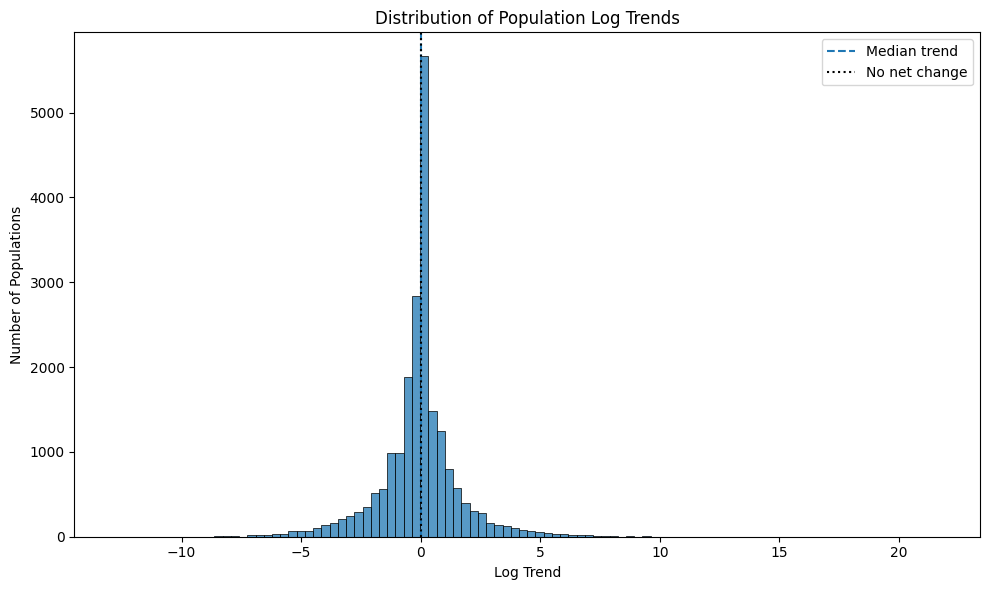

In [10]:
# Plot the overall distribution of calculated log trends.
plt.figure(figsize=(10, 6))

sns.histplot(
    data=trend_data,
    x="Log_Trend",
    bins=100
)

# Add a vertical line for the median trend.
plt.axvline(
    trend_data["Log_Trend"].median(),
    linestyle="--",
    label="Median trend"
)

# Add a vertical line at zero to separate decline from increase.
plt.axvline(
    0,
    color="black",
    linestyle=":",
    label="No net change"
)

plt.title("Distribution of Population Log Trends")
plt.xlabel("Log Trend")
plt.ylabel("Number of Populations")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Calculate key quantiles to describe the distribution numerically.
trend_quantiles = trend_data["Log_Trend"].quantile(
    [0.05, 0.25, 0.50, 0.75, 0.95]
)

trend_quantiles

0.05   -3.002530
0.25   -0.690656
0.50    0.000000
0.75    0.464595
0.95    2.544973
Name: Log_Trend, dtype: float64

## 9. Population trends by vertebrate class

The next question is whether population trends differ between vertebrate classes.  
Only classes with at least 100 monitored populations are used in the main class comparison to avoid over-interpreting very small groups.

In [12]:
# Summarise trend statistics by vertebrate class.
class_trends = (
    trend_data
    .groupby("Class", observed=True)
    .agg(
        Populations=("ID", "count"),
        Mean_Trend=("Log_Trend", "mean"),
        Median_Trend=("Log_Trend", "median"),
        High_Risk_Populations=("High_Risk", "sum")
    )
    .reset_index()
)

# Calculate the percentage of high-risk populations in each class.
class_trends["High_Risk_Share_%"] = (
    class_trends["High_Risk_Populations"] / class_trends["Populations"] * 100
).round(2)

# Sort classes by median trend from strongest decline to strongest increase.
class_trends = class_trends.sort_values("Median_Trend")

class_trends

,Class,Populations,Mean_Trend,Median_Trend,High_Risk_Populations,High_Risk_Share_%
3,Dipneusti,1,-2.456736,-2.456736,1,100.00
1,Amphibia,205,-0.634989,-0.270945,90,43.90
4,Elasmobranchii,397,-0.157711,-0.030893,87,21.91
0,Actinopteri,4847,-0.092210,0.000000,1074,22.16
2,Aves,12476,-0.150820,0.000000,3915,31.38
6,Mammalia,2957,0.127391,0.000000,796,26.92
9,Reptilia,373,0.049503,0.000600,107,28.69
7,Myxini,19,-0.056751,0.003363,3,15.79
5,Holocephali,4,0.019671,0.020643,0,0.00
8,Petromyzonti,5,0.725459,1.271884,1,20.00


In [13]:
# Select major vertebrate classes with enough monitored populations for comparison.
major_classes = class_trends.loc[
    class_trends["Populations"] >= 100,
    "Class"
].tolist()

# Create a filtered dataframe for class-level visualisations.
class_plot_data = trend_data[
    trend_data["Class"].isin(major_classes)
].copy()

print("Major classes included:", major_classes)
print("Class plot dataset shape:", class_plot_data.shape)

Major classes included: ['Amphibia', 'Elasmobranchii', 'Actinopteri', 'Aves', 'Mammalia', 'Reptilia']
Class plot dataset shape: (21255, 16)


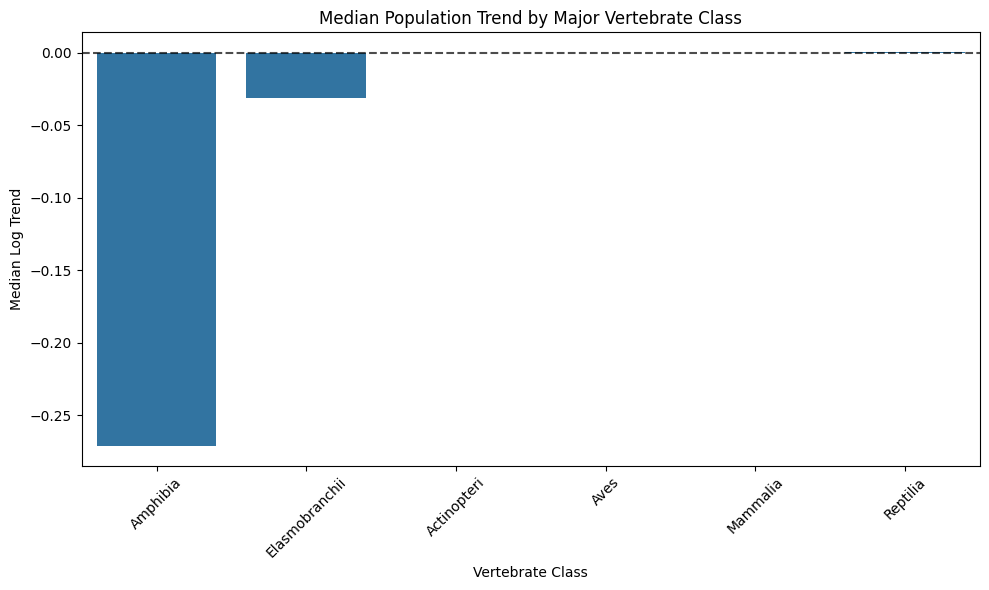

In [14]:
# Plot median log trend by major vertebrate class.
major_class_trends = class_trends[
    class_trends["Class"].isin(major_classes)
].copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=major_class_trends,
    x="Class",
    y="Median_Trend",
    order=major_class_trends["Class"]
)

plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Median Population Trend by Major Vertebrate Class")
plt.xlabel("Vertebrate Class")
plt.ylabel("Median Log Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

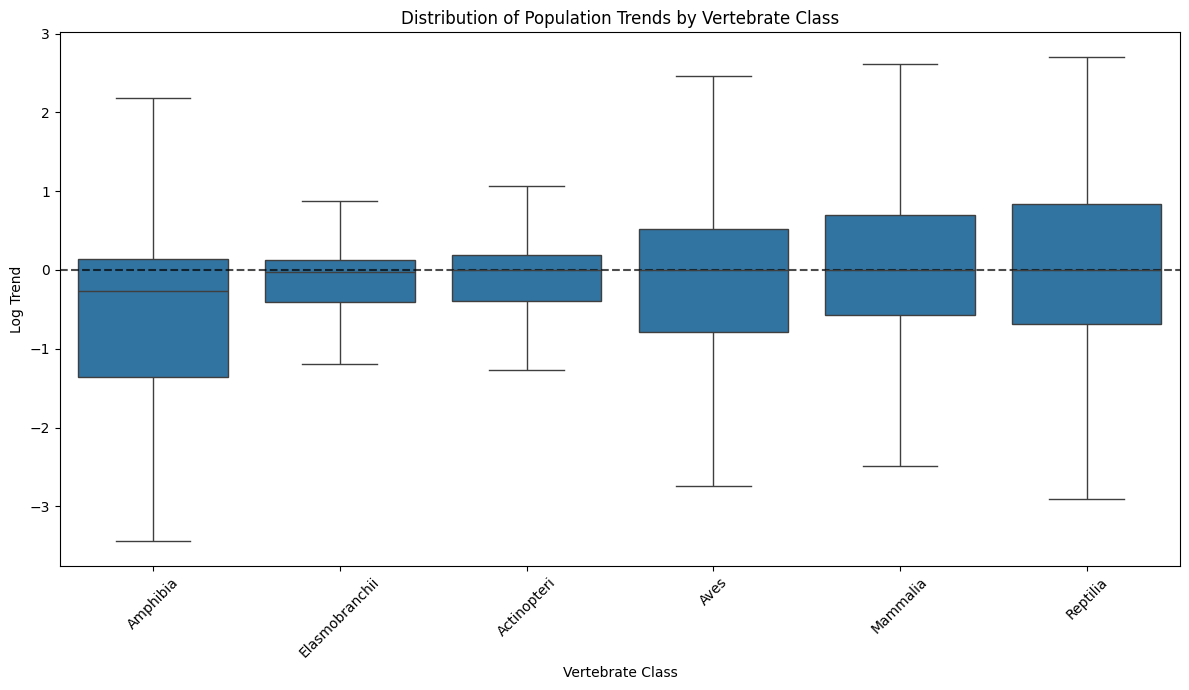

In [15]:
# Plot the full distribution of log trends within each major vertebrate class.
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=class_plot_data,
    x="Class",
    y="Log_Trend",
    order=major_classes,
    showfliers=False
)

plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Distribution of Population Trends by Vertebrate Class")
plt.xlabel("Vertebrate Class")
plt.ylabel("Log Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

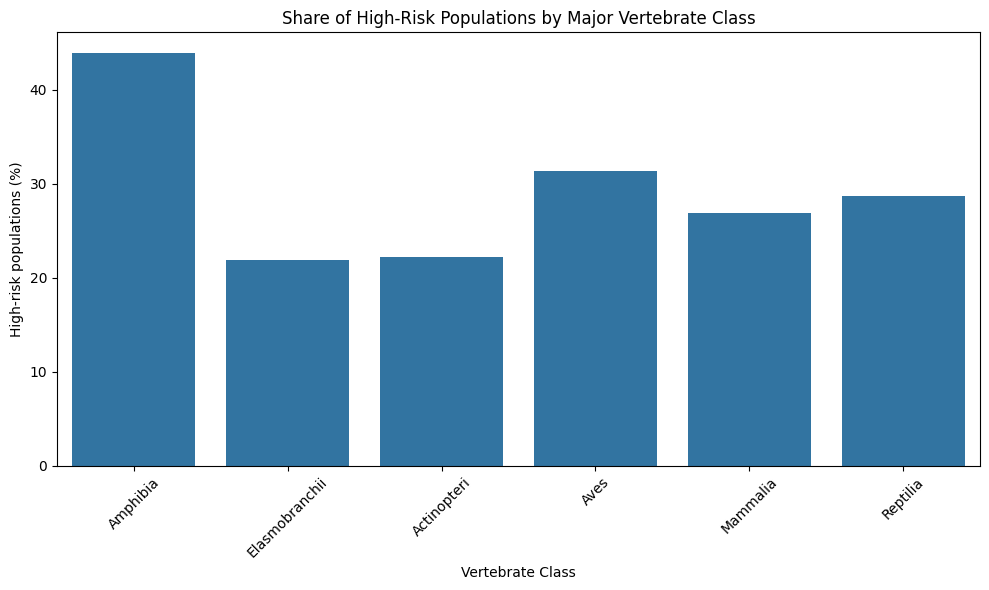

In [16]:
# Plot the share of high-risk populations by major vertebrate class.
plt.figure(figsize=(10, 6))

sns.barplot(
    data=major_class_trends,
    x="Class",
    y="High_Risk_Share_%",
    order=major_class_trends["Class"]
)

plt.title("Share of High-Risk Populations by Major Vertebrate Class")
plt.xlabel("Vertebrate Class")
plt.ylabel("High-risk populations (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Written interpretation

This section answers whether decline patterns differ by vertebrate class.  
The median trend shows the central direction of change, while `High_Risk_Share_%` shows how strongly each class is represented among populations with critical or high decline.

## 10. Population trends by ecosystem system

The Living Planet Database also classifies populations by ecosystem system.  
This section compares trends across freshwater, marine, and terrestrial systems.

In [17]:
# Summarise trend and risk statistics by ecosystem system.
system_trends = (
    trend_data
    .groupby("System", observed=True)
    .agg(
        Populations=("ID", "count"),
        Mean_Trend=("Log_Trend", "mean"),
        Median_Trend=("Log_Trend", "median"),
        High_Risk_Populations=("High_Risk", "sum")
    )
    .reset_index()
)

# Calculate the percentage of high-risk populations in each system.
system_trends["High_Risk_Share_%"] = (
    system_trends["High_Risk_Populations"] / system_trends["Populations"] * 100
).round(2)

# Sort systems by median trend from strongest decline to strongest increase.
system_trends = system_trends.sort_values("Median_Trend")

system_trends

,System,Populations,Mean_Trend,Median_Trend,High_Risk_Populations,High_Risk_Share_%
0,Freshwater,4169,0.131691,0.0,913,21.90
1,Marine,10186,-0.250065,0.0,3366,33.05
2,Terrestrial,6929,-0.018456,0.0,1795,25.91


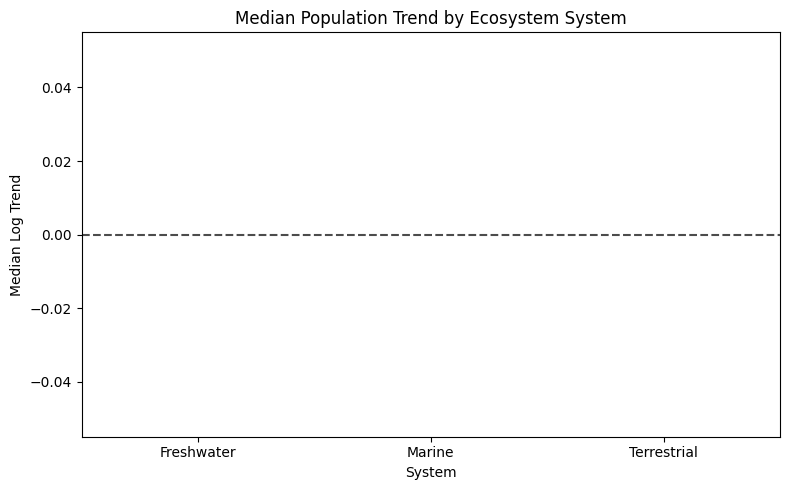

In [18]:
# Plot median log trend by ecosystem system.
plt.figure(figsize=(8, 5))

sns.barplot(
    data=system_trends,
    x="System",
    y="Median_Trend",
    order=system_trends["System"]
)

plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Median Population Trend by Ecosystem System")
plt.xlabel("System")
plt.ylabel("Median Log Trend")
plt.tight_layout()
plt.show()

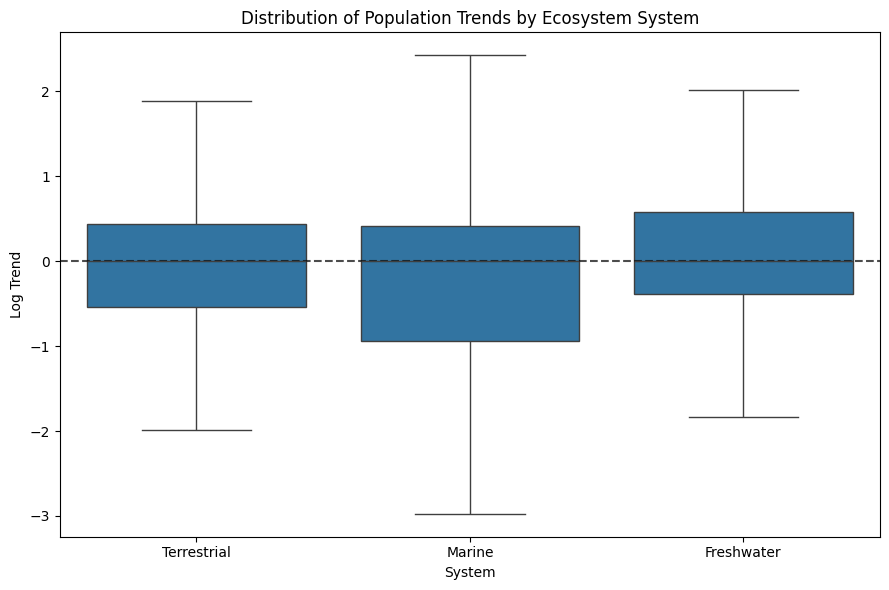

In [19]:
# Plot the full distribution of log trends by ecosystem system.
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=trend_data,
    x="System",
    y="Log_Trend",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Distribution of Population Trends by Ecosystem System")
plt.xlabel("System")
plt.ylabel("Log Trend")
plt.tight_layout()
plt.show()

## 11. Population trends by world region

The final comparison in this notebook looks at broad regional differences.  
Detailed spatial patterns are analysed in the next spatial analysis notebook.

In [20]:
# Summarise trend and risk statistics by world region.
region_summary = (
    trend_data
    .groupby("Region", observed=True)
    .agg(
        Populations=("ID", "count"),
        Mean_Trend=("Log_Trend", "mean"),
        Median_Trend=("Log_Trend", "median"),
        High_Risk_Populations=("High_Risk", "sum")
    )
    .reset_index()
)

# Calculate the percentage of high-risk populations in each region.
region_summary["High_Risk_Share_%"] = (
    region_summary["High_Risk_Populations"] / region_summary["Populations"] * 100
).round(2)

# Sort regions by median trend from strongest decline to strongest increase.
region_summary = region_summary.sort_values("Median_Trend")

region_summary

,Region,Populations,Mean_Trend,Median_Trend,High_Risk_Populations,High_Risk_Share_%
4,International Waters,154,-0.381174,-0.284316,63,40.91
0,Africa,1577,-0.207602,-0.121890,543,34.43
6,North America,5731,-0.025911,-0.000082,1228,21.43
2,Asia,966,-0.073571,0.000000,322,33.33
5,Latin America and Caribbean,2132,-0.098779,0.000000,412,19.32
7,Oceania,6874,-0.466754,0.000000,2706,39.37
3,Europe,3648,0.508164,0.240171,753,20.64
1,Antarctic,202,0.222385,0.253295,47,23.27


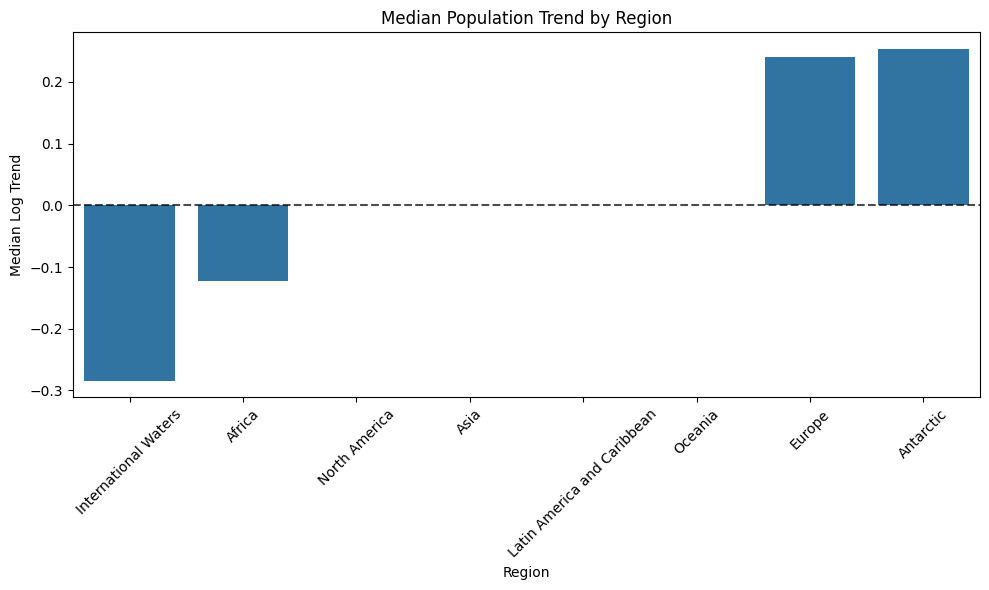

In [21]:
# Plot median log trend by region.
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary,
    x="Region",
    y="Median_Trend",
    order=region_summary["Region"]
)

plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Median Population Trend by Region")
plt.xlabel("Region")
plt.ylabel("Median Log Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

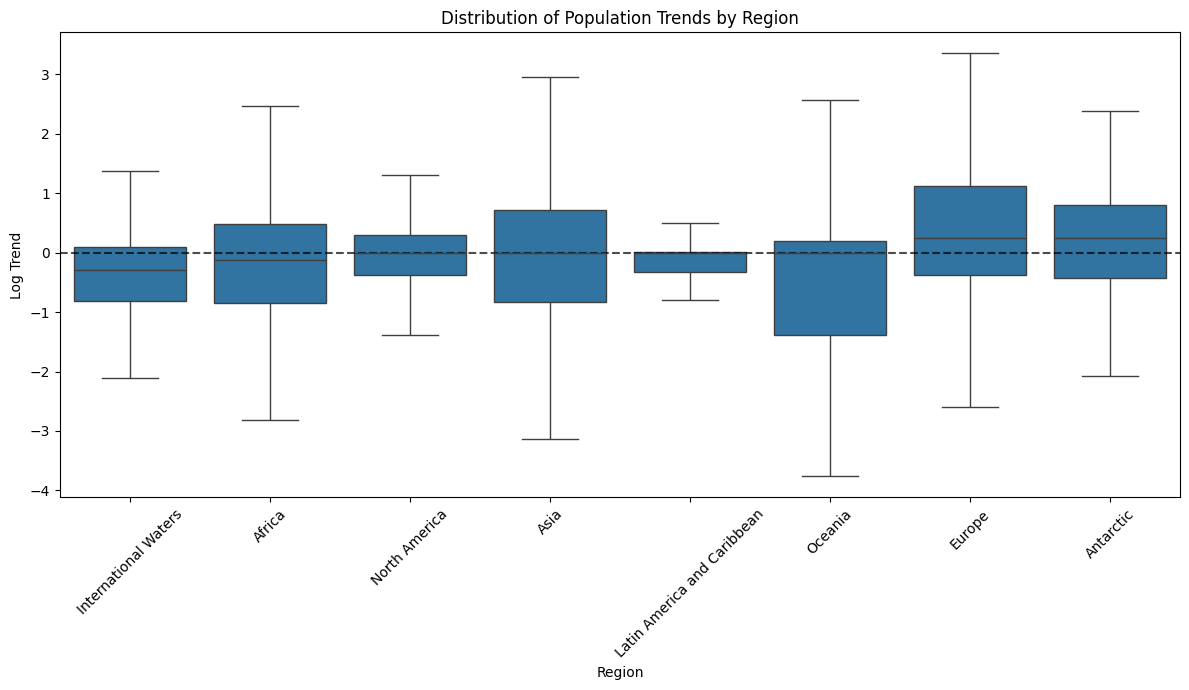

In [22]:
# Plot the distribution of log trends within each region.
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=trend_data,
    x="Region",
    y="Log_Trend",
    order=region_summary["Region"],
    showfliers=False
)

plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Distribution of Population Trends by Region")
plt.xlabel("Region")
plt.ylabel("Log Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Written interpretation

This regional comparison provides the bridge to the next notebook.  
Here, regions are compared as broad categories; the spatial analysis notebook then uses coordinates to examine where high-risk populations are located geographically.

## 12. Save processed trend dataset

The final dataset includes:

- population metadata;
- first and last monitoring years;
- monitoring duration;
- calculated `Log_Trend`;
- consistent `Risk_Category`;
- simplified `High_Risk` flag.

This file is the input for the risk analysis and spatial analysis notebooks.

In [23]:
# Define the processed data directory and create it if it does not already exist.
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Define the output path for the processed trend dataset.
output_path = processed_dir / "lpd_population_trends_with_risk.csv"

# Save the processed trend dataset with risk categories included.
trend_data.to_csv(output_path, index=False)

# Read the saved file back in to verify that important columns were saved correctly.
saved_check = pd.read_csv(output_path)

# Print a clear confirmation message and check key columns.
print("Saved:", output_path)
print("Saved dataset shape:", saved_check.shape)
print("Risk_Category saved:", "Risk_Category" in saved_check.columns)
print("High_Risk saved:", "High_Risk" in saved_check.columns)

# Display a small preview of the saved file.
saved_check[["ID", "Log_Trend", "Risk_Category", "High_Risk"]].head()

Saved: ../data/processed/lpd_population_trends_with_risk.csv
Saved dataset shape: (21284, 16)
Risk_Category saved: True
High_Risk saved: True


,ID,Log_Trend,Risk_Category,High_Risk
0,1,0.920537,Increase,False
1,2,2.632121,Increase,False
2,3,-0.572519,High decline,True
3,4,-0.714653,High decline,True
4,5,3.433987,Increase,False


## Notebook conclusion

This notebook created the main processed population trend dataset for the project.

The key output is a consistent population-level framework:

`Log_Trend → Risk_Category → High_Risk`

This framework keeps the following notebooks aligned: the next notebook analyses risk patterns across taxonomic and ecological groups, and the spatial notebook examines where high-risk populations are geographically concentrated.